In [23]:
import pandas as pd

In [24]:
macro_training_data = pd.read_csv("macro_training_data_features.csv",parse_dates=["aligned_date"])
sentiment_training_data = pd.read_csv("sentiment_training_data_features.csv",parse_dates=["aligned_date"])
all_feature_data = pd.merge(
    sentiment_training_data, 
    macro_training_data, 
    on='aligned_date', 
    how='inner'
)
all_feature_data

,aligned_date,Pos_Score_30day_EMA,Neg_Score_30day_EMA,Neutrality_Ratio_30day_EMA,period_rolling_recession,recession,CPIAUCSL,PAYEMS,UNRATE,INDPRO,...,UMCSENT_MoM,UMCSENT_YoY,UNRATE_MoM_diff,UNRATE_YoY_diff,T10Y3M_MoM_diff,T10Y3M_YoY_diff,T10Y2Y_MoM_diff,T10Y2Y_YoY_diff,BAA10Y_MoM_diff,BAA10Y_YoY_diff
0,2008-03-01,0.124942,0.459353,0.295600,1.0,1.0,212.516,138102.0,4.9,114.2334,...,-0.062252,-0.231270,0.2,0.5,1.00,2.25,0.89,2.04,0.70,1.58
1,2008-04-01,0.142335,0.497481,0.299145,1.0,1.0,212.571,137993.0,4.8,113.6597,...,-0.018362,-0.242094,-0.1,0.3,0.39,2.38,-0.05,1.94,0.23,1.81
2,2008-05-01,0.139617,0.478218,0.310837,1.0,1.0,213.301,137846.0,5.1,112.1281,...,-0.099281,-0.353973,0.3,0.5,0.27,2.94,-0.35,1.57,-0.35,1.50
3,2008-06-01,0.157693,0.448432,0.363876,1.0,1.0,213.743,137818.0,5.0,111.1807,...,-0.044728,-0.323529,-0.1,0.5,-0.17,2.56,-0.08,1.33,-0.10,1.25
4,2008-07-01,0.145640,0.478335,0.356198,1.0,1.0,215.132,137754.0,5.5,110.9051,...,-0.056856,-0.352468,0.5,1.1,-0.08,2.37,-0.04,1.33,0.05,1.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2023-11-01,0.205041,0.452301,0.319152,0.0,0.0,307.481,156874.0,3.8,103.6115,...,-0.060383,0.065109,0.0,0.3,0.25,-0.59,0.25,0.22,0.07,-0.43
176,2023-12-01,0.288294,0.368613,0.436345,0.0,0.0,307.619,156923.0,3.9,102.7081,...,-0.039185,0.079225,0.1,0.2,-0.37,-0.39,-0.17,0.34,-0.18,-0.48
177,2024-01-01,0.320061,0.304784,0.513559,0.0,0.0,307.917,157087.0,3.7,102.6651,...,0.137031,0.167504,-0.2,0.0,-0.44,-0.98,0.01,0.18,-0.06,-0.38
178,2024-03-01,0.341223,0.302135,0.523062,0.0,0.0,309.685,157700.0,3.7,102.5739,...,0.133429,0.217257,0.0,0.2,0.32,-0.02,-0.04,0.30,-0.06,-0.35


Text(0, 0.5, 'Correlation Value')

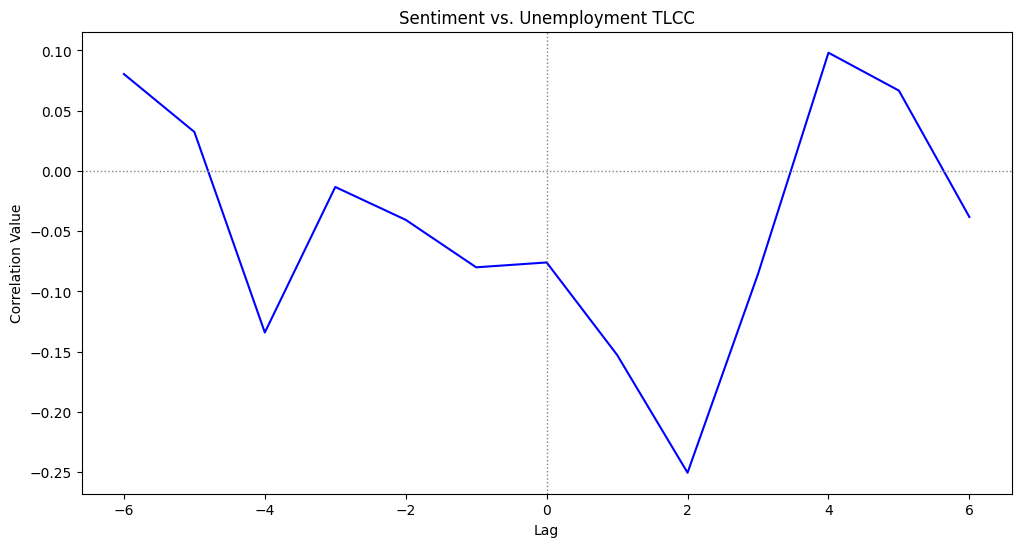

In [25]:
temp_df = all_feature_data[['UNRATE_MoM_diff']].copy()

for lag in range(-6, 7):
    col_name = f'sent_lag_{lag}'
    temp_df[col_name] = all_feature_data['Neutrality_Ratio_30day_EMA'].shift(lag)

temp_df = temp_df.dropna()

correlations = []
for lag in range(-6, 7):
    col_name = f'sent_lag_{lag}'
    corr_value = temp_df[col_name].corr(temp_df['UNRATE_MoM_diff'])
    correlations.append([lag, corr_value])
df = pd.DataFrame(correlations, columns = ['Lag', 'Correlation Value']) 

from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Lag'], df['Correlation Value'], 
         label='Sentiment vs. Unemployment TLCC', color='blue')
plt.axhline(y=0, color='grey', linestyle=':', linewidth=1, label="Neutral Correlation")
plt.axvline(x=0, color='grey', linestyle=':', linewidth=1, label="Neutral Lag")
plt.title('Sentiment vs. Unemployment TLCC')
plt.xlabel('Lag')
plt.ylabel('Correlation Value')

The peak occurs at around a lag of 4 base on the following two factors:
- UNRATE_MoM_diff (Hard Data): Did the unemployment rate go up or down this month?
- Neutrality_Ratio_30day_EMA (Soft Data): Are the financial news headlines leaning positive or negative this month?

So based on this graph: Sentiment from 4 months ago is the best match for the Unemployment changes happening today.

To directly answers your Phase 3 objective: Does the crowd anticipate the data, or react to it?
- A peak at Lag = +4 provides quantitative proof that Sentiment LEADS the hard data by 4 months.

But we have to note that **Correlation of continuous signals (movements) is NOT the same as predicting a binary event (a recession).** 

In [26]:
import joblib
from sklearn.calibration import CalibratedClassifierCV
from datetime import datetime
macro_model = joblib.load('hard_model.joblib')
sentiment_model = joblib.load('soft_model.joblib')

In [27]:
macro_training_unseen = macro_training_data[(macro_training_data["aligned_date"]>=datetime(2018,1,1))& (macro_training_data["aligned_date"]<= datetime(2024,1,1))]
macro_training_unseen_y = macro_training_unseen['target']
macro_training_unseen_x = macro_training_unseen.drop(columns=['recession','target','aligned_date','recession',"CPIAUCSL", "PAYEMS", "INDPRO", "UNRATE", "T10Y3M", "T10Y2Y", "BAA10Y","UMCSENT"])
sentiment_training_unseen = pd.merge(
    macro_training_unseen['aligned_date'] ,
    sentiment_training_data, 
    on='aligned_date', 
    how='inner'
)
sentiment_training_unseen_y = sentiment_training_unseen['period_rolling_recession']
sentiment_training_unseen_x = sentiment_training_unseen.drop(columns=['period_rolling_recession','aligned_date'])
print("macro:",len(macro_training_unseen),"soft:",len(sentiment_training_unseen))

macro: 68 soft: 68


In [28]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator 
frozen_macro_model = FrozenEstimator(macro_model)
calibrated_macro = CalibratedClassifierCV(
    estimator=frozen_macro_model, 
    method='sigmoid'
)
calibrated_macro.fit(macro_training_unseen_x, macro_training_unseen_y)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","FrozenEstimat...ee=None, ...))"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial pr

In [29]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator 
frozen_sentiment_model = FrozenEstimator(sentiment_model)
calibrated_sentiment = CalibratedClassifierCV(
    estimator=frozen_sentiment_model, 
    method='sigmoid'
)
calibrated_sentiment.fit(sentiment_training_unseen_x, sentiment_training_unseen_y)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat...at64(5.3125)))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000


In [30]:
proba_table = macro_training_unseen[['aligned_date','recession']].copy()
macro_proba = calibrated_macro.predict_proba(macro_training_unseen_x)[:,1]
proba_table["macro_probability"] = macro_proba
sentiment_proba = calibrated_sentiment.predict_proba(sentiment_training_unseen_x)[:,1]
proba_table["sentiment_probability"] = sentiment_proba

In [31]:
proba_table["ensemble_probability"] = (sentiment_proba + macro_proba) / 2

In [32]:
proba_table.head(20)

,aligned_date,recession,macro_probability,sentiment_probability,ensemble_probability
184,2018-01-01,0.0,0.112709,0.147907,0.130308
185,2018-02-01,0.0,0.112709,0.147907,0.130308
186,2018-04-01,0.0,0.112709,0.169486,0.141097
187,2018-05-01,0.0,0.112709,0.169169,0.140939
188,2018-06-01,0.0,0.112709,0.147907,0.130308
189,2018-07-01,0.0,0.112709,0.147907,0.130308
190,2018-08-01,0.0,0.112388,0.147907,0.130148
191,2018-09-01,0.0,0.112709,0.147907,0.130308
192,2018-10-01,0.0,0.112709,0.147907,0.130308
193,2018-11-01,0.0,0.112709,0.010569,0.061639


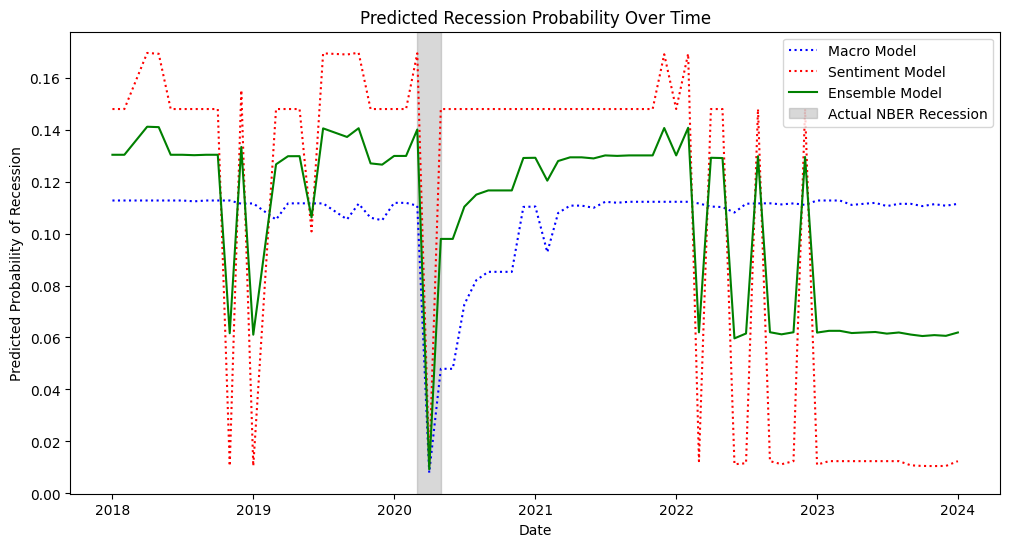

In [33]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))

proba_table['change'] = proba_table['recession'].diff()
starts = proba_table[proba_table['change'] == 1]['aligned_date'].tolist()
ends = proba_table[proba_table['change'] == -1]['aligned_date'].tolist()
if proba_table['recession'].iloc[0] == 1:
    starts.insert(0, proba_table['aligned_date'].iloc[0])
if proba_table['recession'].iloc[-1] == 1:
    ends.append(proba_table['aligned_date'].iloc[-1])

plt.plot(proba_table['aligned_date'], proba_table['macro_probability'], label='Macro Model', color='blue', linestyle=':')
plt.plot(proba_table['aligned_date'], proba_table['sentiment_probability'], label='Sentiment Model', color='red', linestyle=':')
plt.plot(proba_table['aligned_date'], proba_table['ensemble_probability'], label='Ensemble Model', color='green')
for s, e in zip(starts, ends):
    plt.axvspan(s, e, color='gray', alpha=0.3, label='Actual NBER Recession')
plt.title('Predicted Recession Probability Over Time')
plt.xlabel('Date')
plt.ylabel('Predicted Probability of Recession')
plt.legend()

On a purely predictive basis, the model missed the actual recession and predicted a massive one that never materialized.

1. The 2020 Miss (COVID-19): This was an exogenous shock. A model trained on yield curves, employment, and financial news cannot predict a global viral pandemic 6 months in advance.
    - Explaining the dip: During the March 2020 crash, the Fed immediately injected trillions in stimulus. The model saw this "Hard Data" intervention and correctly predicted that 6 months forward, the economy would be recovering. (The COVID recession was the shortest in history at just 2 months).
2. The 2022-2024 False Alarm: During 2022-2023, the 10y-3m Yield Curve inverted to historic levels, CPI ran extremely hot, and the Fed hiked rates aggressively.

The explainability is perhaps a highlight of the limits of historical machine learning when faced with unprecedented macro environments.